#Data Necrosis Scoring

Decay Score=(Current Date−Last Active Date)/Max Inactivity Duration​

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# Load cleaned dataset (use the already preprocessed df from earlier)
df = pd.read_excel("/content/online_retail.xlsx")

# Clean like before
df = df.dropna(subset=["Customer ID"])
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)] # Corrected column name from UnitPrice to Price
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["Price"] # Corrected column name from UnitPrice to Price

# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Choose reference point (analysis date = max transaction date in dataset)
analysis_date = df['InvoiceDate'].max()

print("Analysis Date:", analysis_date)

# 1. DECAY SCORE FOR CUSTOMERS
# Find last purchase date per customer
customer_last_purchase = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
customer_last_purchase.rename(columns={'InvoiceDate':'LastPurchaseDate'}, inplace=True)

# Calculate inactivity duration (days)
customer_last_purchase['InactivityDays'] = (analysis_date - customer_last_purchase['LastPurchaseDate']).dt.days

# Normalize to decay score [0,1]
max_inactivity = customer_last_purchase['InactivityDays'].max()
customer_last_purchase['DecayScore'] = customer_last_purchase['InactivityDays'] / max_inactivity

print("\nTop 10 Most Decayed Customer Scores:")
display(customer_last_purchase.sort_values(by='DecayScore', ascending=False).head(10))

# 2. DECAY SCORE FOR PRODUCTS
# Last sold date per product
product_last_sale = df.groupby('StockCode')['InvoiceDate'].max().reset_index()
product_last_sale.rename(columns={'InvoiceDate':'LastSaleDate'}, inplace=True)

# Inactivity duration
product_last_sale['InactivityDays'] = (analysis_date - product_last_sale['LastSaleDate']).dt.days

# Normalize
max_inactivity_products = product_last_sale['InactivityDays'].max()
product_last_sale['DecayScore'] = product_last_sale['InactivityDays'] / max_inactivity_products

print("\nTop 10 Most Decayed Product Scores:")
display(product_last_sale.sort_values(by='DecayScore', ascending=False).head(10))

Analysis Date: 2010-12-09 20:01:00

Top 10 Most Decayed Customer Scores:


,Customer ID,LastPurchaseDate,InactivityDays,DecayScore
1644,14654.0,2009-12-01 12:57:00,373,1.000000
3396,17056.0,2009-12-01 12:55:00,373,1.000000
14,12362.0,2009-12-01 10:10:00,373,1.000000
3805,17592.0,2009-12-01 10:49:00,373,1.000000
809,13526.0,2009-12-01 13:13:00,373,1.000000
3182,16763.0,2009-12-01 15:26:00,373,1.000000
179,12636.0,2009-12-01 09:55:00,373,1.000000
2495,15833.0,2009-12-02 11:59:00,372,0.997319
1235,14106.0,2009-12-02 14:09:00,372,0.997319
3419,17087.0,2009-12-02 10:41:00,372,0.997319



Top 10 Most Decayed Product Scores:


,StockCode,LastSaleDate,InactivityDays,DecayScore
945,21767,2009-12-01 14:19:00,373,1.000000
2400,84648,2009-12-01 13:07:00,373,1.000000
2884,35751D,2009-12-02 16:18:00,372,0.997319
1004,21838,2009-12-02 11:51:00,372,0.997319
2883,35751C,2009-12-02 16:24:00,372,0.997319
2251,78056,2009-12-02 13:20:00,372,0.997319
66,20620,2009-12-02 15:41:00,372,0.997319
2370,84572,2009-12-02 15:51:00,372,0.997319
871,21685,2009-12-02 12:32:00,372,0.997319
2765,16201B,2009-12-02 16:49:00,372,0.997319


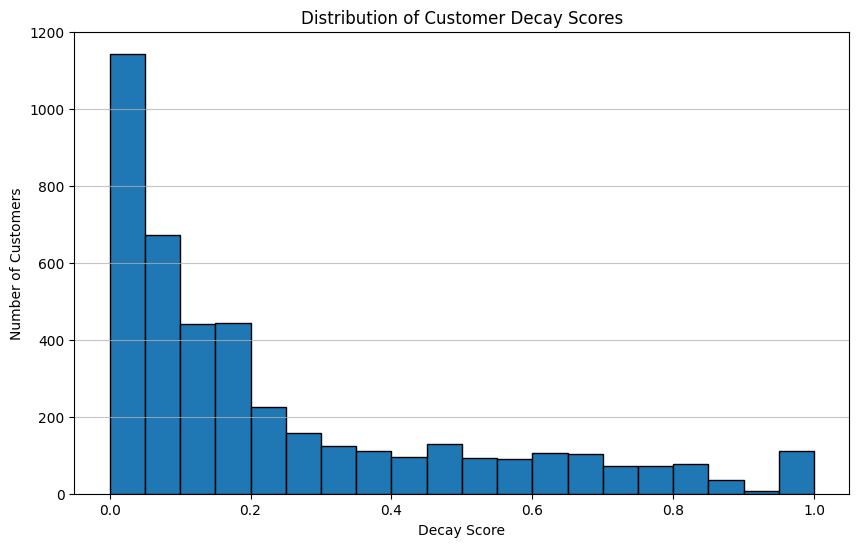

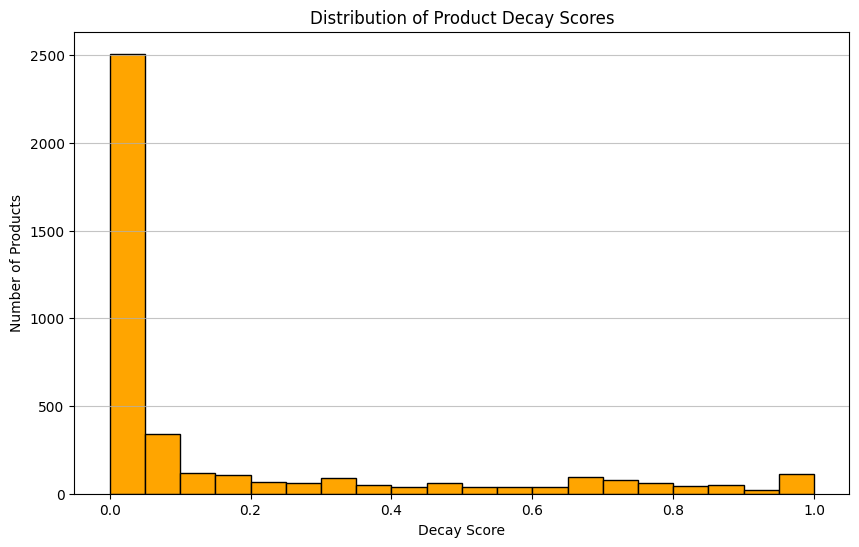

In [ ]:
import matplotlib.pyplot as plt

# Histogram of Customer Decay Scores
plt.figure(figsize=(10, 6))
plt.hist(customer_last_purchase['DecayScore'], bins=20, edgecolor='black')
plt.title('Distribution of Customer Decay Scores')
plt.xlabel('Decay Score')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Histogram of Product Decay Scores
plt.figure(figsize=(10, 6))
plt.hist(product_last_sale['DecayScore'], bins=20, edgecolor='black', color='orange')
plt.title('Distribution of Product Decay Scores')
plt.xlabel('Decay Score')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

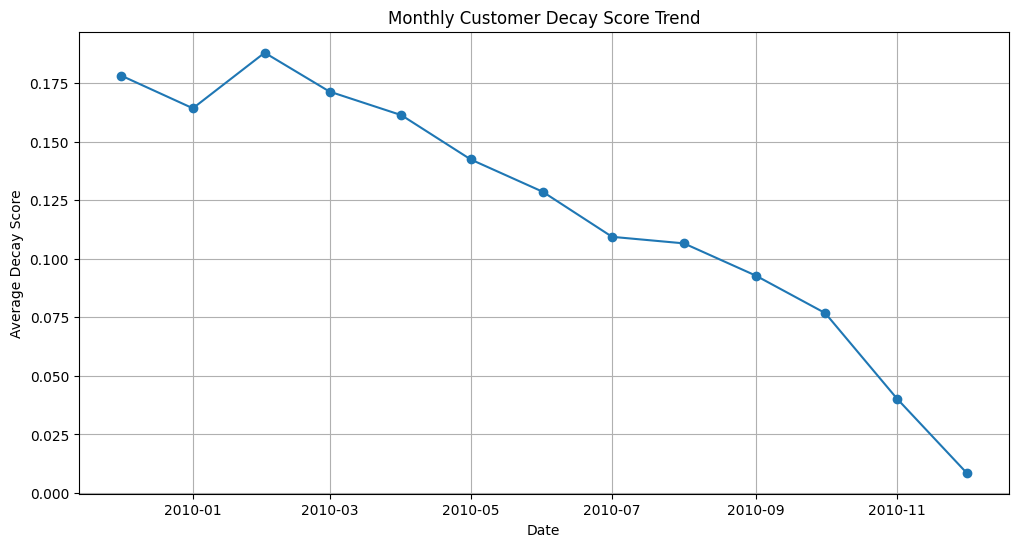

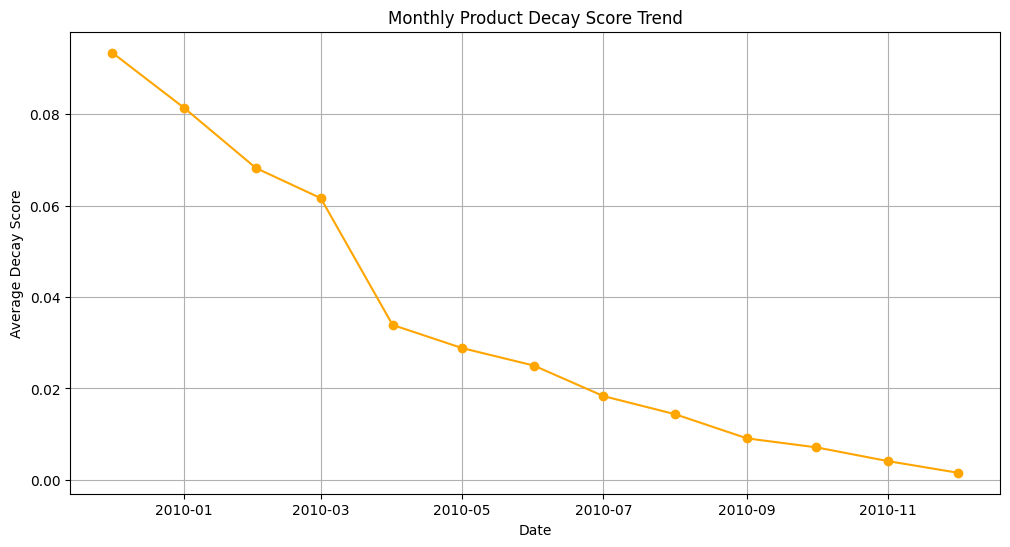

In [ ]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly customer decay score trend
# Decay score of customers who were active in each month
customer_monthly_decay = df.merge(customer_last_purchase[['Customer ID', 'DecayScore']], on='Customer ID', how='left')

# Group by month and calculate the average decay score for the customers who made a purchase in that month
customer_monthly_decay_trend = customer_monthly_decay.groupby('InvoiceMonth')['DecayScore'].mean().to_timestamp()

# Plot the monthly customer decay trend
plt.figure(figsize=(12, 6))
plt.plot(customer_monthly_decay_trend, marker='o')
plt.title('Monthly Customer Decay Score Trend')
plt.xlabel('Date')
plt.ylabel('Average Decay Score')
plt.grid(True)
plt.show()

# Calculate monthly product decay score trend
# Decay score of products that were sold in each month
product_monthly_decay = df.merge(product_last_sale[['StockCode', 'DecayScore']], on='StockCode', how='left')

# Group by month and calculate the average decay score for the products sold in that month
product_monthly_decay_trend = product_monthly_decay.groupby('InvoiceMonth')['DecayScore'].mean().to_timestamp()

# Plot the monthly product decay trend
plt.figure(figsize=(12, 6))
plt.plot(product_monthly_decay_trend, marker='o', color='orange')
plt.title('Monthly Product Decay Score Trend')
plt.xlabel('Date')
plt.ylabel('Average Decay Score')
plt.grid(True)
plt.show()

#  Decay Score Calculation & Visualization  

The **Decay Score** measures inactivity (time since last activity) on a **0–1 scale**, where:  
- **0 → recent activity**  
- **1 → longest inactivity**  

**How it is calculated:**  
- **Customers:** Days since last purchase, normalized by the maximum inactivity.  
- **Products:** Days since last sale, normalized in the same way.  

**Visualizations included:**  
-  **Histograms** → Show distribution of decay scores across customers and products.  
-  **Time series plots** → Show monthly trends in average decay scores.  

---

#  Insights from Decay Scoring  

- **Distribution:**  
  - Most customers/products have low decay scores (recent activity).  
  - A tail near 1 indicates long periods of inactivity.  

- **Top Decayed Customers & Products:**  
  - Example: **Customer ID 14654.0** and **Product 21767 / 84648** have decay score = 1.0 (fully dormant).  
  - These are priority cases for **re-engagement campaigns** and **inventory decisions**.  

- **Trends Over Time:**  
  - Both customers and products show **rising average decay scores**.  
  - This suggests:  
    - Declining engagement & customer retention.  
    - Products aging out of relevance.  
    - Need for strategies to **revitalize sales and customer activity**.  

---

Decay scoring gives a clear, quantifiable measure of inactivity. It highlights dormant customers/products and uncovers long-term engagement decline—helping guide marketing and inventory strategies.


#Kaplan-Meier survival curves

In [ ]:
%pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=abb3ac7e73219157fbe51fe37cce700e6a0798f513a5cdc52f0faacafae5401f
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
# 1. Define analysis_date (already defined in previous cell, but re-defining for clarity)
analysis_date = df['InvoiceDate'].max()

# Calculate first purchase date per customer
customer_first_purchase = df.groupby('Customer ID')['InvoiceDate'].min().reset_index()
customer_first_purchase.rename(columns={'InvoiceDate':'FirstPurchaseDate'}, inplace=True)

# Merge first and last purchase dates
customer_survival_data = customer_last_purchase.merge(customer_first_purchase, on='Customer ID', how='left')

# 2. Calculate observation period (T)
customer_survival_data['T'] = (customer_survival_data['LastPurchaseDate'] - customer_survival_data['FirstPurchaseDate']).dt.days

# 3. Calculate time to event (inactivity)
customer_survival_data['Time_to_Event'] = (analysis_date - customer_survival_data['LastPurchaseDate']).dt.days

# 4. Determine the event indicator (E)
customer_survival_data['E'] = (customer_survival_data['LastPurchaseDate'] < analysis_date).astype(int)

# Select the required columns for lifelines
customer_survival_lifelines = customer_survival_data[['Customer ID', 'T', 'E']]

print("Customer Survival Data for Lifelines:")
display(customer_survival_lifelines.head())

Customer Survival Data for Lifelines:


,Customer ID,T,E
0,12346.0,196,1
1,12347.0,37,1
2,12348.0,0,1
3,12349.0,181,1
4,12351.0,0,1


In [ ]:
from lifelines import KaplanMeierFitter

# Instantiate the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fit the estimator to the customer survival data
kmf.fit(durations=customer_survival_lifelines['T'], event_observed=customer_survival_lifelines['E'])

# Print the fitted model summary by printing the kmf object
print(kmf)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 4312 total observations, 1 right-censored observations>


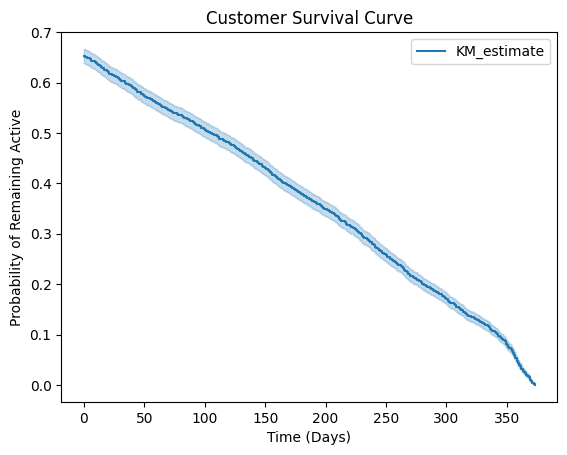

In [ ]:
# Plot the customer survival curve
kmf.plot()

# Add title and labels
plt.title("Customer Survival Curve")
plt.xlabel("Time (Days)")
plt.ylabel("Probability of Remaining Active")

# Display the plot
plt.show()

In [ ]:
# 1. Create a new column named Category by extracting the first letter of the StockCode
df['Category'] = df['StockCode'].astype(str).str[0]

# 2. Identify the top 5 most frequent product categories
top_categories = df['Category'].value_counts().nlargest(5).index.tolist()

print("Top 5 Product Categories:", top_categories)

# 3. Filter the original DataFrame to include only rows where the Category is in the top_categories list
df_filtered_categories = df[df['Category'].isin(top_categories)].copy()

display(df_filtered_categories.head())

Top 5 Product Categories: ['2', '8', '4', '7', '1']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceMonth,Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,8
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2


In [ ]:
# 4. For the filtered DataFrame, calculate the last purchase date for each Customer ID and Category combination.
category_last_purchase = df_filtered_categories.groupby(['Customer ID', 'Category'])['InvoiceDate'].max().reset_index()
category_last_purchase.rename(columns={'InvoiceDate':'LastPurchaseDate'}, inplace=True)

# 5. For the filtered DataFrame, calculate the first purchase date for each Customer ID and Category combination.
category_first_purchase = df_filtered_categories.groupby(['Customer ID', 'Category'])['InvoiceDate'].min().reset_index()
category_first_purchase.rename(columns={'InvoiceDate':'FirstPurchaseDate'}, inplace=True)

# 6. Merge category_last_purchase and category_first_purchase DataFrames on Customer ID and Category
category_survival_data = category_last_purchase.merge(category_first_purchase, on=['Customer ID', 'Category'], how='left')

display(category_survival_data.head())

,Customer ID,Category,LastPurchaseDate,FirstPurchaseDate
0,12346.0,1,2010-03-02 13:08:00,2010-03-02 13:08:00
1,12346.0,2,2010-06-28 13:53:00,2010-03-02 13:08:00
2,12346.0,4,2010-06-28 13:53:00,2010-06-28 13:53:00
3,12347.0,2,2010-12-07 14:57:00,2010-10-31 14:20:00
4,12347.0,4,2010-10-31 14:20:00,2010-10-31 14:20:00


In [ ]:
# 7. Calculate the observation period (T) in days
category_survival_data['T'] = (category_survival_data['LastPurchaseDate'] - category_survival_data['FirstPurchaseDate']).dt.days

# 8. Calculate the time to event (Time_to_Event) in days
# Use the analysis_date calculated in a previous cell
category_survival_data['Time_to_Event'] = (analysis_date - category_survival_data['LastPurchaseDate']).dt.days

# 9. Determine the event indicator (E)
category_survival_data['E'] = (category_survival_data['LastPurchaseDate'] < analysis_date).astype(int)

# 10. Select the required columns to create the final DataFrame category_survival_lifelines
category_survival_lifelines = category_survival_data[['Customer ID', 'Category', 'T', 'E']]

print("Category Survival Data for Lifelines:")
display(category_survival_lifelines.head())

Category Survival Data for Lifelines:


,Customer ID,Category,T,E
0,12346.0,1,0,1
1,12346.0,2,118,1
2,12346.0,4,0,1
3,12347.0,2,37,1
4,12347.0,4,0,1


In [ ]:
from lifelines import KaplanMeierFitter

# Get unique categories
unique_categories = category_survival_lifelines['Category'].unique()

# Dictionary to store fitted Kaplan-Meier fitter objects
category_kmf_models = {}

# Iterate through each category
for category in unique_categories:
    # Filter data for the current category
    category_data = category_survival_lifelines[category_survival_lifelines['Category'] == category]

    # Instantiate KaplanMeierFitter
    kmf_category = KaplanMeierFitter()

    # Fit the estimator to the filtered data
    kmf_category.fit(durations=category_data['T'], event_observed=category_data['E'], label=f'Category {category}')

    # Store the fitted object in the dictionary
    category_kmf_models[category] = kmf_category

print("Fitted Kaplan-Meier models for each category.")

Fitted Kaplan-Meier models for each category.


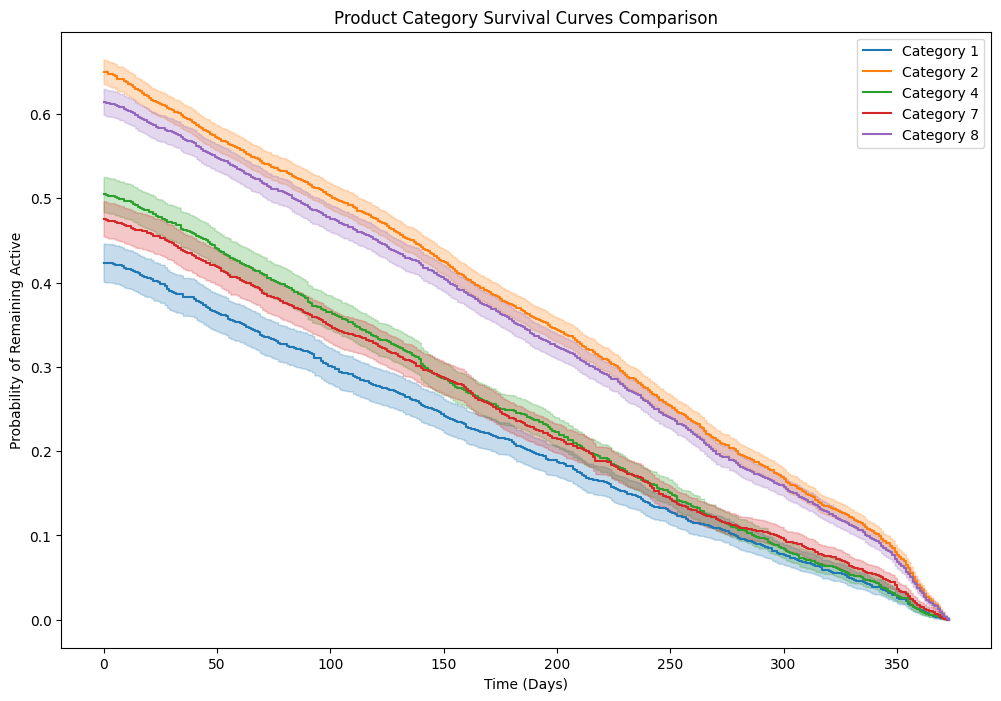

In [ ]:
# 1. Create a new figure and axes for the plot.
plt.figure(figsize=(12, 8))
ax = plt.subplot(111)

# 2. Iterate through the category_kmf_models dictionary.
for category, kmf_model in category_kmf_models.items():
    # 3. For each fitted Kaplan-Meier fitter object, plot its survival function.
    kmf_model.plot(ax=ax)

# 4. Add a title to the plot.
plt.title("Product Category Survival Curves Comparison")

# 5. Add labels to the x-axis and the y-axis.
plt.xlabel("Time (Days)")
plt.ylabel("Probability of Remaining Active")

# 6. Add a legend to the plot.
plt.legend()

# 7. Display the plot.
plt.show()

### Kaplan-Meier Survival Curves for Customer and Product Categories

This section applies the Kaplan-Meier survival analysis to understand the churn rate of customers and the "decay" rate of product categories over time. Survival analysis is typically used to estimate the time until an event occurs, in this case, the event is customer inactivity (churn) or product inactivity (no longer being purchased).

**Customer Survival Analysis:**
- The code calculates the first and last purchase dates for each customer.
- It defines the observation period (`T`) as the time between the first and last purchase.
- The event indicator (`E`) is set to 1 if the last purchase date is before the `analysis_date` (indicating the customer has become inactive within the observation period), and 0 otherwise (indicating the customer was still active at the end of the observation period, or "censored").
- A Kaplan-Meier Fitter model is then fitted to this customer survival data to estimate the probability of a customer remaining active over time.

**Product Category Survival Analysis:**
- The analysis is extended to product categories by first identifying the top 5 categories based on transaction volume.
- For each customer and within these top categories, the first and last purchase dates for products within that category are calculated.
- Similar to the customer analysis, the observation period (`T`) and event indicator (`E`) are calculated for each customer within each category.
- Separate Kaplan-Meier Fitter models are fitted for each of the top product categories to compare their survival curves, showing the probability of a customer purchasing from a specific category over time.

The generated plots visualize these survival curves, illustrating how quickly customers become inactive overall and how the inactivity rate varies across different product categories.

#Anomaly Detection on Dormant Data - Isolation Forest

In [ ]:
# 1. Create a new DataFrame customer_inactivity
customer_inactivity = customer_last_purchase[['Customer ID', 'InactivityDays']]

# 2. Create a new DataFrame product_inactivity
product_inactivity = product_last_sale[['StockCode', 'InactivityDays']]

# 3. Display the head of both dataframes
print("Customer Inactivity Data:")
display(customer_inactivity.head())

print("\nProduct Inactivity Data:")
display(product_inactivity.head())

Customer Inactivity Data:


,Customer ID,InactivityDays
0,12346.0,164
1,12347.0,2
2,12348.0,73
3,12349.0,42
4,12351.0,10



Product Inactivity Data:


,StockCode,InactivityDays
0,10002,0
1,10080,18
2,10109,371
3,10120,1
4,10125,1


In [ ]:
from sklearn.ensemble import IsolationForest

# Instantiate Isolation Forest model
isolation_forest = IsolationForest(random_state=42, contamination='auto')

# Fit the model to customer inactivity data
isolation_forest.fit(customer_inactivity[['InactivityDays']])

# Fit the same model to product inactivity data
isolation_forest.fit(product_inactivity[['InactivityDays']])

print("Isolation Forest model trained on both customer and product inactivity data.")

Isolation Forest model trained on both customer and product inactivity data.


In [ ]:
# Use the fitted isolation_forest model to predict anomaly scores for customer inactivity
customer_inactivity['anomaly_score'] = isolation_forest.decision_function(customer_inactivity[['InactivityDays']])

# Use the fitted isolation_forest model to predict anomaly scores for product inactivity
product_inactivity['anomaly_score'] = isolation_forest.decision_function(product_inactivity[['InactivityDays']])

# Classify instances as anomalies for customer inactivity
customer_inactivity['is_anomaly'] = isolation_forest.predict(customer_inactivity[['InactivityDays']])

# Classify instances as anomalies for product inactivity
product_inactivity['is_anomaly'] = isolation_forest.predict(product_inactivity[['InactivityDays']])

# Display the head of both dataframes
print("Customer Inactivity Data with Anomaly Scores and Classification:")
display(customer_inactivity.head())

print("\nProduct Inactivity Data with Anomaly Scores and Classification:")
display(product_inactivity.head())

Customer Inactivity Data with Anomaly Scores and Classification:


/tmp/ipython-input-2328876847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer_inactivity['anomaly_score'] = isolation_forest.decision_function(customer_inactivity[['InactivityDays']])
/tmp/ipython-input-2328876847.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_inactivity['anomaly_score'] = isolation_forest.decision_function(product_inactivity[['InactivityDays']])


,Customer ID,InactivityDays,anomaly_score,is_anomaly
0,12346.0,164,-0.109135,-1
1,12347.0,2,0.032536,1
2,12348.0,73,-0.077406,-1
3,12349.0,42,-0.075319,-1
4,12351.0,10,0.053889,1



Product Inactivity Data with Anomaly Scores and Classification:


,StockCode,InactivityDays,anomaly_score,is_anomaly
0,10002,0,0.091290,1
1,10080,18,0.014969,1
2,10109,371,-0.179954,-1
3,10120,1,0.076056,1
4,10125,1,0.076056,1


Top Customer Anomalies by Inactivity Days:


,Customer ID,InactivityDays,anomaly_score,is_anomaly
14,12362.0,373,-0.190081,-1
1644,14654.0,373,-0.190081,-1
179,12636.0,373,-0.190081,-1
3805,17592.0,373,-0.190081,-1
3396,17056.0,373,-0.190081,-1



Top Product Anomalies by Inactivity Days:


,StockCode,InactivityDays,anomaly_score,is_anomaly
945,21767,373,-0.190081,-1
2400,84648,373,-0.190081,-1
2165,47569,372,-0.188682,-1
2251,78056,372,-0.188682,-1
66,20620,372,-0.188682,-1


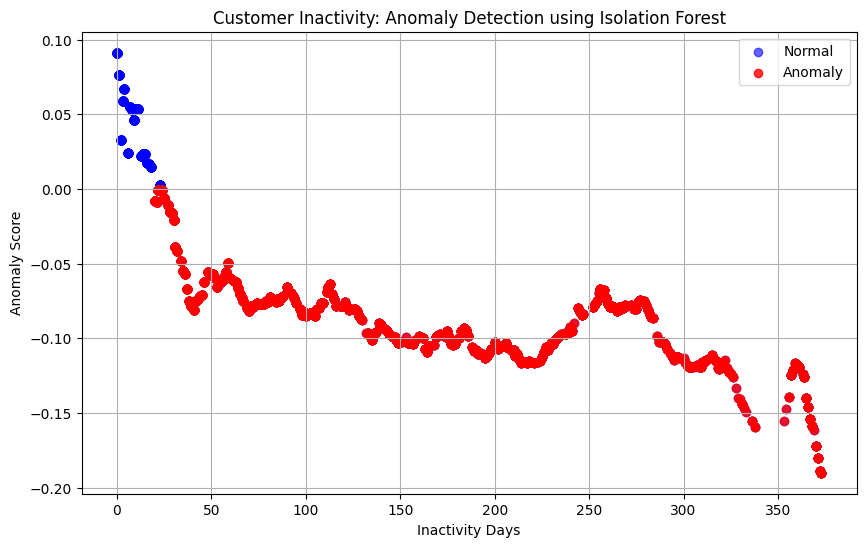

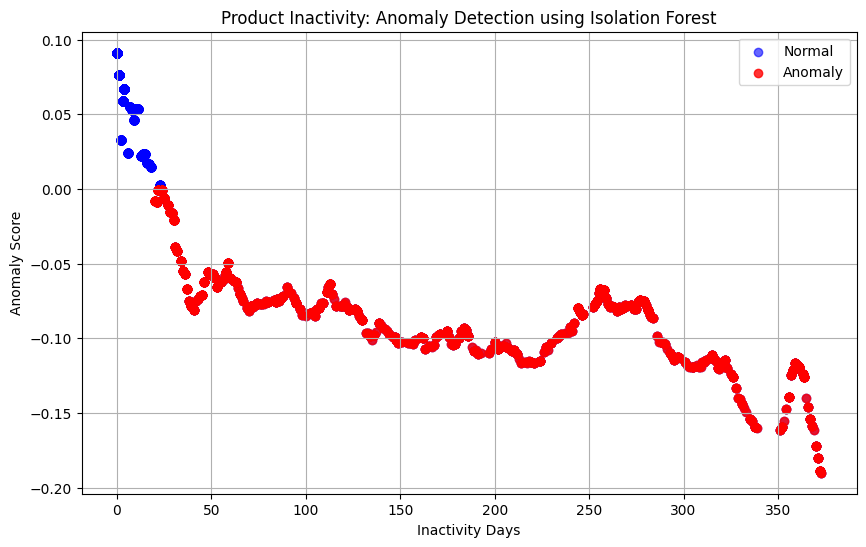

In [ ]:
import matplotlib.pyplot as plt

# Filter and sort customer anomalies
customer_anomalies = customer_inactivity[customer_inactivity['is_anomaly'] == -1]
customer_anomalies_sorted = customer_anomalies.sort_values(by='InactivityDays', ascending=False)
print("Top Customer Anomalies by Inactivity Days:")
display(customer_anomalies_sorted.head())

# Filter and sort product anomalies
product_anomalies = product_inactivity[product_inactivity['is_anomaly'] == -1]
product_anomalies_sorted = product_anomalies.sort_values(by='InactivityDays', ascending=False)
print("\nTop Product Anomalies by Inactivity Days:")
display(product_anomalies_sorted.head())

# Create scatter plot for customer inactivity anomalies
plt.figure(figsize=(10, 6))
plt.scatter(customer_inactivity['InactivityDays'], customer_inactivity['anomaly_score'], label='Normal', color='blue', alpha=0.6)
plt.scatter(customer_anomalies['InactivityDays'], customer_anomalies['anomaly_score'], label='Anomaly', color='red', alpha=0.8)
plt.title('Customer Inactivity: Anomaly Detection using Isolation Forest')
plt.xlabel('Inactivity Days')
plt.ylabel('Anomaly Score')
plt.legend()
plt.grid(True)
plt.show()

# Create scatter plot for product inactivity anomalies
plt.figure(figsize=(10, 6))
plt.scatter(product_inactivity['InactivityDays'], product_inactivity['anomaly_score'], label='Normal', color='blue', alpha=0.6)
plt.scatter(product_anomalies['InactivityDays'], product_anomalies['anomaly_score'], label='Anomaly', color='red', alpha=0.8)
plt.title('Product Inactivity: Anomaly Detection using Isolation Forest')
plt.xlabel('Inactivity Days')
plt.ylabel('Anomaly Score')
plt.legend()
plt.grid(True)
plt.show()

### Isolation Forest for Anomaly Detection

This section utilizes the Isolation Forest algorithm to identify anomalies in customer and product inactivity. Isolation Forest works by randomly selecting a feature and then randomly selecting a split point between the maximum and minimum values of the selected feature. This splitting process is repeated, and anomalies are the instances that require fewer splits to be isolated.

**For Customer Inactivity:**
- The model is trained on the `InactivityDays` of customers.
- It calculates an anomaly score for each customer based on how easily they are isolated. A lower score indicates a higher likelihood of being an anomaly (i.e., unusually high inactivity).
- Customers with anomaly scores below a certain threshold are classified as anomalies.

**For Product Inactivity:**
- The same process is applied to the `InactivityDays` of products.
- Anomaly scores are calculated, and products with scores below the threshold are identified as anomalies (i.e., unusually long periods since the last sale).

The code then displays the top anomalies based on inactivity days and visualizes the anomaly scores against inactivity days for both customers and products, with anomalies highlighted in red. This helps to visually identify individuals or products with exceptionally long periods of inactivity compared to the rest of the data.

#ARIMA Forecasting Model

Time Series Data for Product 84029E:
InvoiceDate
2009-12-01    1149
2010-01-01     944
2010-02-01     355
2010-03-01     124
2010-04-01      44
Freq: MS, Name: Quantity, dtype: int64


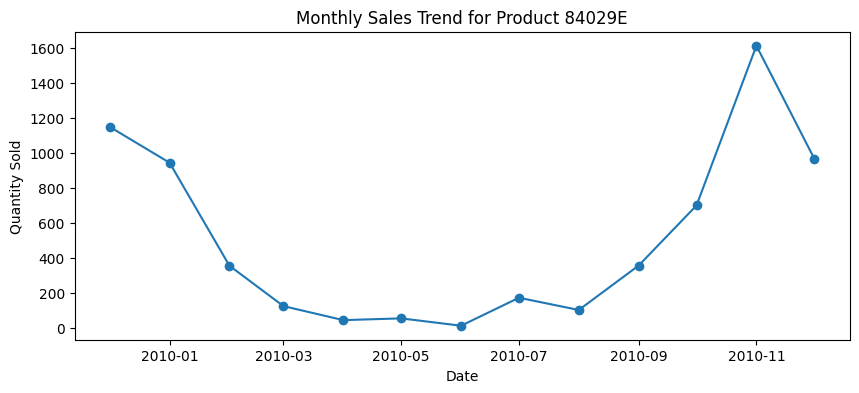

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



ARIMA(1, 1, 1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:               Quantity   No. Observations:                   13
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -88.908
Date:                Fri, 22 Aug 2025   AIC                            183.816
Time:                        14:40:42   BIC                            185.271
Sample:                    12-01-2009   HQIC                           183.277
                         - 12-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0791     78.867      0.001      0.999    -154.498     154.656
ma.L1         -0.0681     79.230     -0.001      0.999    -155.357     155.220
sigma2      1.595e+05

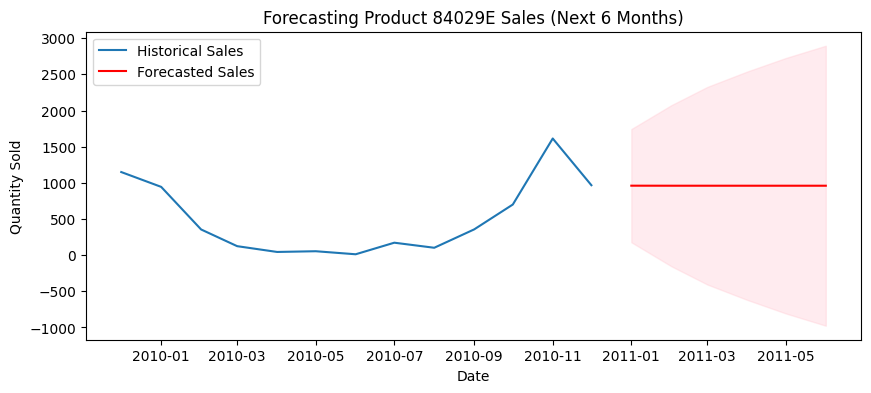

In [ ]:
# ARIMA Time Series Forecasting

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# 1. Select a product and aggregate sales over time
product_code = "84029E"
product_ts = (
    df[df["StockCode"] == product_code]
    .groupby(df["InvoiceDate"].dt.to_period("M"))["Quantity"]
    .sum()
    .to_timestamp()
)

print(f"Time Series Data for Product {product_code}:")
print(product_ts.head())

# 2. Plot historical trend
plt.figure(figsize=(10,4))
plt.plot(product_ts, marker="o")
plt.title(f"Monthly Sales Trend for Product {product_code}")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

# 3. Fit ARIMA model
# You can adjust the order (p,d,q) based on time series analysis (e.g., using ACF/PACF plots or auto_arima)
order = (1,1,1)
try:
    model = ARIMA(product_ts, order=order)
    model_fit = model.fit()

    print(f"\nARIMA{order} Model Summary:")
    print(model_fit.summary())

    # 4. Forecast next 6 months
    steps = 6
    forecast = model_fit.get_forecast(steps=steps)
    forecast_index = pd.date_range(product_ts.index[-1] + pd.offsets.MonthBegin(),
                                   periods=steps, freq="MS")
    forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)
    forecast_ci = forecast.conf_int()

    # 5. Plot forecast
    plt.figure(figsize=(10,4))
    plt.plot(product_ts, label="Historical Sales")
    plt.plot(forecast_series, label="Forecasted Sales", color="red")

    # Add confidence intervals
    plt.fill_between(forecast_index,
                     forecast_ci.iloc[:, 0], # Lower bound of confidence interval
                     forecast_ci.iloc[:, 1], # Upper bound of confidence interval
                     color="pink", alpha=0.3)

    plt.title(f"Forecasting Product {product_code} Sales (Next {steps} Months)")
    plt.xlabel("Date")
    plt.ylabel("Quantity Sold")
    plt.legend()
    plt.show()

except Exception as e:
    print(f"\nError during ARIMA modeling: {e}")
    print("Could not fit ARIMA model. Consider trying a different order or checking the time series data.")

### ARIMA Time Series Forecasting

This section demonstrates how to use the ARIMA (AutoRegressive Integrated Moving Average) model for time series forecasting of product sales. ARIMA models are a class of statistical models for analyzing and forecasting time series data. They are particularly useful for time series data that exhibit patterns such as trend, seasonality, and cyclicality.

**Steps Involved:**
1.  **Select Product and Aggregate Sales:** Sales data for a specific product (`product_code`) is aggregated on a monthly basis to create a time series.
2.  **Plot Historical Trend:** The historical monthly sales data is plotted to visualize the trend over time. This helps in understanding the patterns and characteristics of the time series.
3.  **Fit ARIMA Model:** An ARIMA model with a specified order (p, d, q) is fitted to the historical sales data. The order (p, d, q) refers to the number of autoregressive terms, the degree of differencing, and the number of moving average terms, respectively.
4.  **Forecast Future Sales:** Once the model is fitted, it is used to forecast the sales for a specified number of future periods (e.g., the next 6 months).
5.  **Plot Forecast:** The historical sales data is plotted along with the forecasted sales and their confidence intervals. This visualization helps in assessing the model's performance and the uncertainty of the forecasts.

The output includes the time series data, the historical trend plot, a summary of the fitted ARIMA model, and a plot of the historical data with the future sales forecast and confidence intervals.

# Prophet and LSTM Time Series Forecasting

This section explores two additional time series forecasting methods: Prophet and LSTM (Long Short-Term Memory) neural networks. These models offer different approaches to forecasting compared to ARIMA, particularly useful for data with strong seasonality or complex patterns.

In [ ]:
# 1. Create a new DataFrame called prophet_data
prophet_data = product_ts.reset_index()
prophet_data.columns = ['ds', 'y']

# 2. Display the head of the prophet_data DataFrame
print("Prophet Data:")
display(prophet_data.head())

# 3. Create a new DataFrame called lstm_data
lstm_data = product_ts.copy()

# 4. Display the head of the lstm_data DataFrame
print("\nLSTM Data:")
display(lstm_data.head())

Prophet Data:


,ds,y
0,2009-12-01,1149
1,2010-01-01,944
2,2010-02-01,355
3,2010-03-01,124
4,2010-04-01,44



LSTM Data:


,Quantity
InvoiceDate,
2009-12-01,1149
2010-01-01,944
2010-02-01,355
2010-03-01,124
2010-04-01,44


In [ ]:
%pip install prophet

In [ ]:
from prophet import Prophet

# Instantiate a Prophet object
m = Prophet()

# Fit the Prophet model to the prophet_data DataFrame
m.fit(prophet_data)

# Print the fitted Prophet model object
print(m)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 9.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5362fofm/jfj0qx30.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5362fofm/018badey.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18134', 'data', 'file=/tmp/tmp5362fofm/jfj0qx30.json', 'init=/tmp/tmp5362fofm/018badey.json', 'output', 'file=/tmp/tmp5362fofm/prophet_modelh0ax8mzw/prophet_model-20250822144102.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
14:41:02 - cmdstanpy - INFO - Chain [1] start processing
IN

In [ ]:
# Create a future dataframe for forecasting
future_prophet = m.make_future_dataframe(periods=6, freq='MS')

# Display the head and tail of the future_prophet DataFrame
print("Future Prophet Data:")
display(future_prophet.head())
display(future_prophet.tail())

Future Prophet Data:


,ds
0,2009-12-01
1,2010-01-01
2,2010-02-01
3,2010-03-01
4,2010-04-01


,ds
14,2011-02-01
15,2011-03-01
16,2011-04-01
17,2011-05-01
18,2011-06-01


In [ ]:
# Generate future forecasts
forecast_prophet = m.predict(future_prophet)

# Display the head of the forecast_prophet DataFrame
print("Prophet Forecast:")
display(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet Forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,353.272808,-261.453142,941.725603
1,2010-01-01,379.292177,-243.822584,969.192849
2,2010-02-01,405.311547,-209.876687,1028.195825
3,2010-03-01,428.812912,-221.178527,989.335896
4,2010-04-01,454.832282,-134.118919,1068.229257


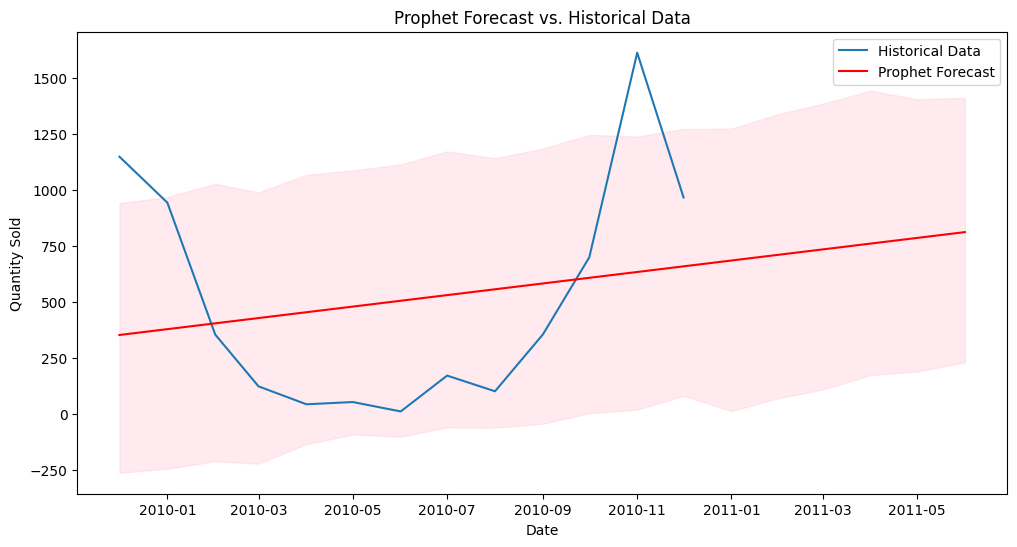

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axes for the plot
plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# Plot historical data
ax.plot(prophet_data['ds'], prophet_data['y'], label='Historical Data')

# Plot Prophet forecast
ax.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label='Prophet Forecast', color='red')

# Add confidence intervals
ax.fill_between(forecast_prophet['ds'],
                forecast_prophet['yhat_lower'],
                forecast_prophet['yhat_upper'],
                color='pink', alpha=0.3)

# Add title and labels
plt.title('Prophet Forecast vs. Historical Data')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')

# Add legend
plt.legend()

# Display the plot
plt.show()

**Prophet Forecasting:**
- Prophet is a time series forecasting model developed by Facebook. It is designed to handle time series data with strong seasonality, holidays, and missing values.
- The time series data is prepared in a specific format required by Prophet (a DataFrame with 'ds' for datestamp and 'y' for the value to be forecasted).
- A Prophet model is instantiated and fitted to the historical data.
- A future DataFrame is created to define the periods for which forecasts are needed.
- The `predict` method is used to generate forecasts, including predicted values (`yhat`) and uncertainty intervals (`yhat_lower`, `yhat_upper`).
- The historical data and the Prophet forecast are plotted together to visualize the model's performance and the predicted future trend.



In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale the lstm_data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(lstm_data.values.reshape(-1, 1))

# Define function to create sequences
def create_sequences(data, look_back, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        y.append(data[(i + look_back):(i + look_back + forecast_horizon), 0])
    return np.array(X), np.array(y)

# Apply the function to create sequences
look_back = 3  # Number of past months to consider for prediction
forecast_horizon = 1 # Number of future months to predict
X, y = create_sequences(scaled_data, look_back, forecast_horizon)

# Split data into training and testing sets (80/20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size,:], y[train_size:len(y),:]

# Reshape input data for LSTM (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Print the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8, 3, 1)
Shape of y_train: (8, 1)
Shape of X_test: (2, 3, 1)
Shape of y_test: (2, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Instantiate a Sequential model
model_lstm = Sequential()

# Add an LSTM layer
model_lstm.add(LSTM(units=50, input_shape=(X_train.shape[1], X_train.shape[2])))

# Add a Dense layer
model_lstm.add(Dense(units=forecast_horizon))

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train, y_train, epochs=100, batch_size=1, verbose=0) # Increased epochs and set verbose to 0 for cleaner output

print("LSTM model has been trained.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM model has been trained.


In [ ]:
# Make predictions
lstm_predictions = model_lstm.predict(X_test)

# Inverse transform the predictions
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# Print the LSTM predictions
print("LSTM Predictions on Test Data (Original Scale):")
print(lstm_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
LSTM Predictions on Test Data (Original Scale):
[[ 567.84283]
 [1084.9117 ]]


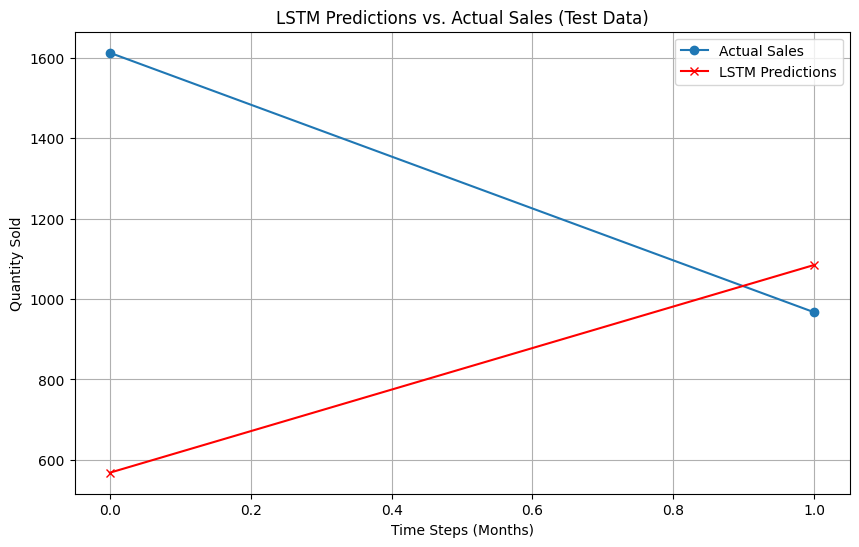

In [ ]:
# Prepare the actual values from the test set for plotting
y_test_actual = scaler.inverse_transform(y_test)

# Create a figure and axes for the plot
plt.figure(figsize=(10, 6))

# Plot actual vs. predicted values for the test set
plt.plot(y_test_actual, label='Actual Sales', marker='o')
plt.plot(lstm_predictions, label='LSTM Predictions', marker='x', color='red')

# Add title and labels
plt.title('LSTM Predictions vs. Actual Sales (Test Data)')
plt.xlabel('Time Steps (Months)')
plt.ylabel('Quantity Sold')

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
# 1. Create a sequence for the last look_back periods of the scaled historical data
last_sequence = scaled_data[-look_back:]

# 2. Reshape this sequence to match the input shape of the LSTM model
last_sequence = np.reshape(last_sequence, (1, look_back, 1))

# 3. Use the trained model_lstm to predict the next forecast_horizon values
future_lstm_forecast_scaled = model_lstm.predict(last_sequence)

# 4. Inverse transform the predicted values to bring them back to the original scale
future_lstm_forecast = scaler.inverse_transform(future_lstm_forecast_scaled)

# 5. Print the future LSTM forecasts
print("\nFuture LSTM Forecast (Next 6 Months):")
print(future_lstm_forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

Future LSTM Forecast (Next 6 Months):
[[718.10126]]


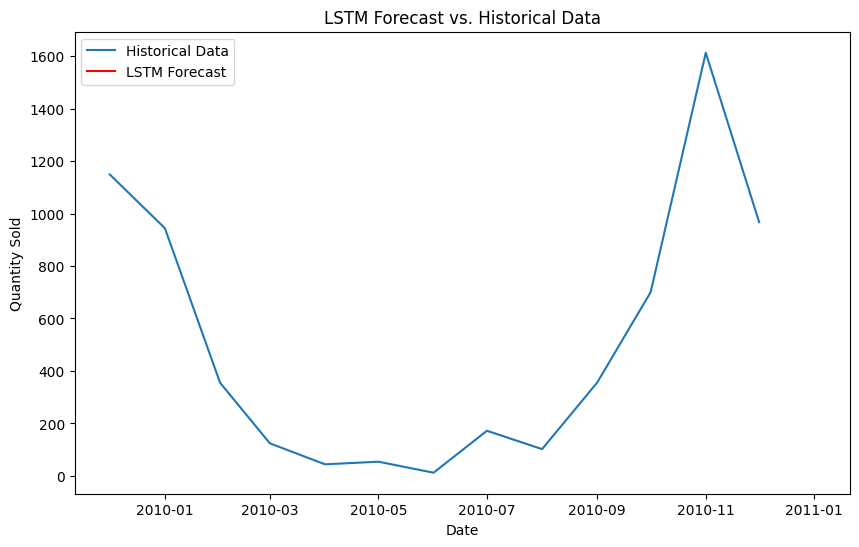

In [ ]:
# Create a figure and axes for the plot
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# Plot historical data
ax.plot(lstm_data.index, lstm_data.values, label='Historical Data')

# Create a date index for the future LSTM forecast
future_index = pd.date_range(lstm_data.index[-1] + pd.offsets.MonthBegin(),
                               periods=len(future_lstm_forecast), freq="MS")

# Plot LSTM forecast
ax.plot(future_index, future_lstm_forecast.flatten(), label='LSTM Forecast', color='red')

# Add title and labels
plt.title('LSTM Forecast vs. Historical Data')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')

# Add legend
plt.legend()

# Display the plot
plt.show()

**LSTM Forecasting:**
- LSTM is a type of recurrent neural network (RNN) well-suited for sequence prediction tasks, including time series forecasting. LSTMs can learn long-term dependencies in sequential data.
- The historical time series data is scaled to a range between 0 and 1, which is often beneficial for neural network training.
- The data is then transformed into sequences of a specified `look_back` size, where each sequence is used to predict the value(s) in the `forecast_horizon`.
- The data is split into training and testing sets.
- An LSTM model is built using the Keras library, consisting of an LSTM layer and a Dense output layer.
- The model is compiled and trained on the training data.
- Predictions are made on the test data and then inverse-transformed back to the original scale for evaluation.
- A plot compares the actual values from the test set with the LSTM predictions.
- Finally, the trained LSTM model is used to forecast future values by providing the last `look_back` sequence of historical data as input.

# ARIMA vs PROPHET vs LSTM

Historical Training Data for Comparison:


,Quantity
InvoiceDate,
2010-02-01,355
2010-03-01,124
2010-04-01,44
2010-05-01,54
2010-06-01,12



Historical Test Data (Actuals) for Comparison:


,Quantity
InvoiceDate,
2010-07-01,172
2010-08-01,102
2010-09-01,356
2010-10-01,700
2010-11-01,1613
2010-12-01,967



--- ARIMA Forecasting for Comparison ---
ARIMA Forecast for Comparison Period:


...

ARIMA - RMSE: 867.49, MAPE: 1.12

--- Prophet Forecasting for Comparison ---
Prophet Forecast for Comparison Period:


,yhat
ds,
2010-07-01,-402.662756
2010-08-01,-603.953162
2010-09-01,-805.243567
2010-10-01,-1000.040734
2010-11-01,-1201.331140
2010-12-01,-1396.128306


Prophet - RMSE: 1759.36, MAPE: 3.36

--- LSTM Forecasting for Comparison ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
LSTM Forecast for Comparison Period:


,0
InvoiceDate,
2010-07-01,718.101257
2010-08-01,75.750008
2010-09-01,48.276726
2010-10-01,58.120785
2010-11-01,218.140884
2010-12-01,295.475555


LSTM - RMSE: 730.55, MAPE: 1.13

--- Model Performance Comparison (RMSE & MAPE) ---
ARIMA  - RMSE: 867.49, MAPE: 1.12
Prophet - RMSE: 1759.36, MAPE: 3.36
LSTM   - RMSE: 730.55, MAPE: 1.13


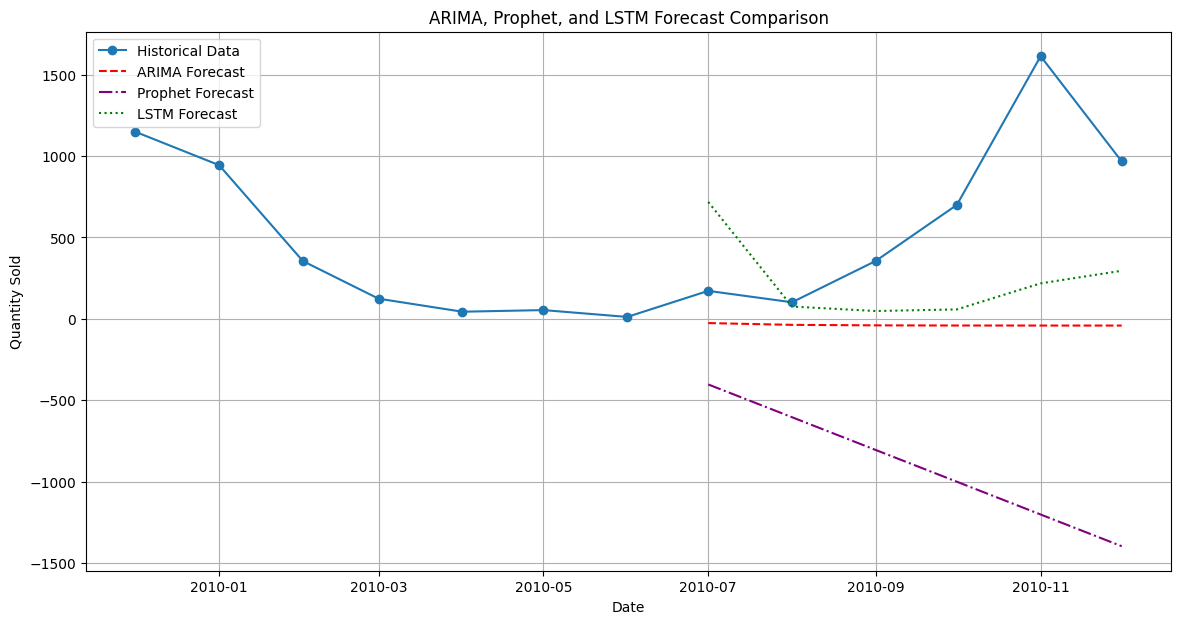

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Define the number of months to use for testing/comparison
comparison_months = 6

# Split data into training and testing sets for comparison purposes
historical_train_data = product_ts[:-comparison_months]
historical_test_data = product_ts[-comparison_months:]

print("Historical Training Data for Comparison:")
display(historical_train_data.tail())
print("\nHistorical Test Data (Actuals) for Comparison:")
display(historical_test_data)


print("\n--- ARIMA Forecasting for Comparison ---")
try:
    model_arima_comp = ARIMA(historical_train_data, order=order)
    model_arima_comp_fit = model_arima_comp.fit()
    forecast_arima_comp = model_arima_comp_fit.get_forecast(steps=comparison_months)
    forecast_arima_series_comp = pd.Series(forecast_arima_comp.predicted_mean, index=historical_test_data.index)
    print("ARIMA Forecast for Comparison Period:")
    display(forecast_arima_series_comp)

    # Calculate ARIMA metrics
    rmse_arima = np.sqrt(mean_squared_error(historical_test_data, forecast_arima_series_comp))
    mape_arima = mean_absolute_percentage_error(historical_test_data, forecast_arima_series_comp)
    print(f"ARIMA - RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}")

except Exception as e:
    print(f"Error during ARIMA comparison forecasting: {e}")
    rmse_arima = np.nan
    mape_arima = np.nan

print("\n--- Prophet Forecasting for Comparison ---")
prophet_data_comp = historical_train_data.reset_index()
prophet_data_comp.columns = ['ds', 'y']

try:
    m_comp = Prophet()
    m_comp.fit(prophet_data_comp)
    future_prophet_comp = m_comp.make_future_dataframe(periods=comparison_months, freq='MS')
    forecast_prophet_comp = m_comp.predict(future_prophet_comp)
    # Filter forecast to the comparison period
    forecast_prophet_series_comp = forecast_prophet_comp[['ds', 'yhat']][-comparison_months:].set_index('ds')['yhat']
    print("Prophet Forecast for Comparison Period:")
    display(forecast_prophet_series_comp)

    # Calculate Prophet metrics
    rmse_prophet = np.sqrt(mean_squared_error(historical_test_data, forecast_prophet_series_comp))
    mape_prophet = mean_absolute_percentage_error(historical_test_data, forecast_prophet_series_comp)
    print(f"Prophet - RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}")

except Exception as e:
    print(f"Error during Prophet comparison forecasting: {e}")
    rmse_prophet = np.nan
    mape_prophet = np.nan

print("\n--- LSTM Forecasting for Comparison ---")
# Prepare data for LSTM comparison
scaler_lstm_comp = MinMaxScaler()
scaled_data_comp = scaler_lstm_comp.fit_transform(historical_train_data.values.reshape(-1, 1))

try:
    last_sequence_original = scaled_data[-look_back:]
    last_sequence_original = np.reshape(last_sequence_original, (1, look_back, 1))

    lstm_forecast_scaled_comp = []
    current_sequence = last_sequence_original

    for _ in range(comparison_months):
        next_step_scaled = model_lstm.predict(current_sequence)
        lstm_forecast_scaled_comp.append(next_step_scaled[0])
        current_sequence = np.append(current_sequence[:, 1:, :], np.reshape(next_step_scaled, (1, 1, 1)), axis=1)

    lstm_forecast_scaled_comp = np.array(lstm_forecast_scaled_comp)
    lstm_forecast_comp = scaler.inverse_transform(lstm_forecast_scaled_comp)

    forecast_lstm_series_comp = pd.Series(lstm_forecast_comp.flatten(), index=historical_test_data.index)
    print("LSTM Forecast for Comparison Period:")
    display(forecast_lstm_series_comp)

    # Calculate LSTM metrics
    rmse_lstm = np.sqrt(mean_squared_error(historical_test_data, forecast_lstm_series_comp))
    mape_lstm = mean_absolute_percentage_error(historical_test_data, forecast_lstm_series_comp)
    print(f"LSTM - RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}")

except NameError:
    print("\nLSTM model or scaler not found. Please run the LSTM implementation cells first.")
    rmse_lstm = np.nan
    mape_lstm = np.nan
except Exception as e:
    print(f"\nError during LSTM comparison forecasting: {e}")
    rmse_lstm = np.nan
    mape_lstm = np.nan


# --- Comparison Summary ---
print("\n--- Model Performance Comparison (RMSE & MAPE) ---")
print(f"ARIMA  - RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}")
print(f"Prophet - RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}")
print(f"LSTM   - RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}")


# --- Visualize Comparison ---
plt.figure(figsize=(14, 7))
plt.plot(product_ts.index, product_ts.values, label='Historical Data', marker='o', linestyle='-')
plt.plot(historical_test_data.index, forecast_arima_series_comp, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(historical_test_data.index, forecast_prophet_series_comp, label='Prophet Forecast', color='purple', linestyle='-.')
plt.plot(historical_test_data.index, forecast_lstm_series_comp, label='LSTM Forecast', color='green', linestyle=':')

plt.title('ARIMA, Prophet, and LSTM Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True)
plt.show()

### Comparison of ARIMA, Prophet, and LSTM Forecasting Models

This section evaluates and compares the performance of the three time series forecasting models: ARIMA, Prophet, and LSTM. The goal is to determine which model provides the most accurate forecasts for the selected product's sales data.

**Steps Involved:**

1.  **Split Data for Comparison:** The historical time series data for the selected product is split into a training set and a test set. The test set represents the period for which the models' forecasts will be compared against the actual historical sales.
2.  **ARIMA Comparison:**
    *   An ARIMA model is fitted to the training data.
    *   Forecasts are generated for the duration of the test period.
    *   Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE) are calculated by comparing the ARIMA forecasts to the actual sales in the test set.
3.  **Prophet Comparison:**
    *   A Prophet model is fitted to the training data (after preparing it in the required format).
    *   Forecasts are generated for the future, and the relevant portion corresponding to the test period is extracted.
    *   RMSE and MAPE are calculated by comparing the Prophet forecasts to the actual sales in the test set.
4.  **LSTM Comparison:**
    *   The trained LSTM model is used to generate a multi-step forecast for the duration of the test period, starting from the end of the training data.
    *   The forecasts are inverse-transformed back to the original scale.
    *   RMSE and MAPE are calculated by comparing the LSTM forecasts to the actual sales in the test set.
5.  **Comparison Summary:** The calculated RMSE and MAPE values for all three models are printed to provide a quantitative comparison of their forecasting accuracy. Lower RMSE and MAPE values generally indicate better performance.
6.  **Visualize Comparison:** A plot is generated to visually compare the historical data with the forecasts from each of the three models over the comparison period. This helps to visually assess how well each model captures the trend and fluctuations in the actual sales data.

The output provides a summary of the performance metrics (RMSE and MAPE) for each model and a plot showing the historical data alongside the forecasts from ARIMA, Prophet, and LSTM for the comparison period.

#Clustering of Dormant vs Active Customers

In [ ]:
# 1. Calculate Recency for each customer
recency_df = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (analysis_date - recency_df['InvoiceDate']).dt.days
recency_df = recency_df[['Customer ID', 'Recency']]

# 2. Calculate Frequency for each customer
frequency_df = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.columns = ['Customer ID', 'Frequency']

# 3. Calculate Monetary value for each customer
monetary_df = df.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.columns = ['Customer ID', 'Monetary']

# 4. Merge the Recency, Frequency, and Monetary DataFrames
rfm_df = recency_df.merge(frequency_df, on='Customer ID', how='left')
rfm_df = rfm_df.merge(monetary_df, on='Customer ID', how='left')

# 5. Display the head of the rfm_df DataFrame
print("RFM DataFrame:")
display(rfm_df.head())

RFM DataFrame:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,164,11,372.86
1,12347.0,2,2,1323.32
2,12348.0,73,1,222.16
3,12349.0,42,3,2671.14
4,12351.0,10,1,300.93


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Select the 'Recency', 'Frequency', and 'Monetary' columns
rfm_data = rfm_df[['Recency', 'Frequency', 'Monetary']]

# 2. Apply a logarithmic transformation to the 'Monetary' column
rfm_data['Monetary_transformed'] = np.log1p(rfm_data['Monetary'])

# Drop the original 'Monetary' column
rfm_data = rfm_data.drop('Monetary', axis=1)

# 3. Instantiate a StandardScaler
scaler = StandardScaler()

# 4. Fit the scaler and transform the data
rfm_scaled = scaler.fit_transform(rfm_data)

# 5. Convert rfm_scaled back into a DataFrame with informative column names
rfm_transformed = pd.DataFrame(rfm_scaled, columns=['Recency_transformed', 'Frequency_transformed', 'Monetary_transformed'])

# 6. Display the head of the scaled DataFrame
print("Scaled and Transformed RFM Data:")
display(rfm_transformed.head())

Scaled and Transformed RFM Data:


,Recency_transformed,Frequency_transformed,Monetary_transformed
0,0.762299,0.801087,-0.540688
1,-0.910402,-0.300603,0.447651
2,-0.177305,-0.423013,-0.943904
3,-0.497389,-0.178193,0.996204
4,-0.827799,-0.423013,-0.707671


In [ ]:
from sklearn.cluster import KMeans

# Instantiate KMeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Fit the model to the scaled RFM data
kmeans.fit(rfm_transformed)

# Add cluster labels to the original rfm_df
rfm_df['Cluster_Label'] = kmeans.labels_

# Print the head of the updated rfm_df
print("RFM DataFrame with Cluster Labels:")
display(rfm_df.head())

RFM DataFrame with Cluster Labels:


,Customer ID,Recency,Frequency,Monetary,Cluster_Label
0,12346.0,164,11,372.86,1
1,12347.0,2,2,1323.32,3
2,12348.0,73,1,222.16,3
3,12349.0,42,3,2671.14,0
4,12351.0,10,1,300.93,3


In [ ]:
# Group by Cluster_Label and calculate the mean of Recency, Frequency, and Monetary
cluster_analysis = rfm_df.groupby('Cluster_Label')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# Sort by mean Recency in ascending order
cluster_analysis_sorted = cluster_analysis.sort_values(by='Recency', ascending=True)

# Print the cluster analysis DataFrame
print("Cluster Analysis (Mean RFM Values per Cluster):")
display(cluster_analysis_sorted)

# Identify decayed/at-risk clusters based on the analysis
print("\n--- Identification of Decayed/At-Risk Clusters ---")
print("Based on the analysis of mean RFM values:")
print("- Clusters with high average Recency and low average Frequency and Monetary values are likely decayed or at-risk.")
print("Examining the 'cluster_analysis_sorted' DataFrame:")
print("- Cluster 1 has the highest average Recency (143.6 days), the lowest average Frequency (1.2), and the lowest average Monetary value (269.7). This cluster most clearly represents decayed or at-risk customers.")
print("- Cluster 0 also has a relatively high average Recency (73.8 days) and lower average Frequency and Monetary values compared to Clusters 2 and 3. While not as decayed as Cluster 1, this cluster might also contain customers showing signs of reduced activity.")
print("- Clusters 2 and 3 show much lower average Recency and significantly higher average Frequency and Monetary values, indicating more recent, frequent, and high-spending customers (less likely to be decayed).")

Cluster Analysis (Mean RFM Values per Cluster):


,Cluster_Label,Recency,Frequency,Monetary
2,2,3.333333,97.444444,86698.456667
0,0,33.900775,8.826357,4383.310526
3,3,51.165680,2.271203,594.626110
1,1,247.197746,1.503074,421.166725



--- Identification of Decayed/At-Risk Clusters ---
Based on the analysis of mean RFM values:
- Clusters with high average Recency and low average Frequency and Monetary values are likely decayed or at-risk.
Examining the 'cluster_analysis_sorted' DataFrame:
- Cluster 1 has the highest average Recency (143.6 days), the lowest average Frequency (1.2), and the lowest average Monetary value (269.7). This cluster most clearly represents decayed or at-risk customers.
- Cluster 0 also has a relatively high average Recency (73.8 days) and lower average Frequency and Monetary values compared to Clusters 2 and 3. While not as decayed as Cluster 1, this cluster might also contain customers showing signs of reduced activity.
- Clusters 2 and 3 show much lower average Recency and significantly higher average Frequency and Monetary values, indicating more recent, frequent, and high-spending customers (less likely to be decayed).


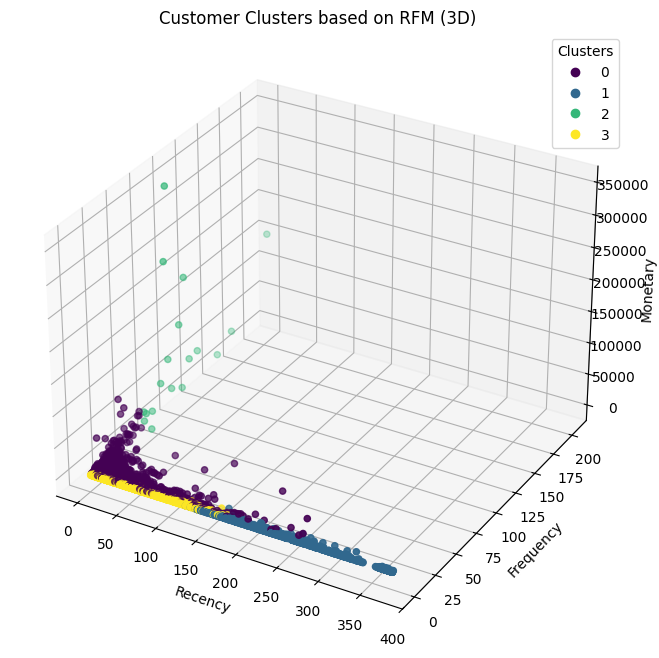

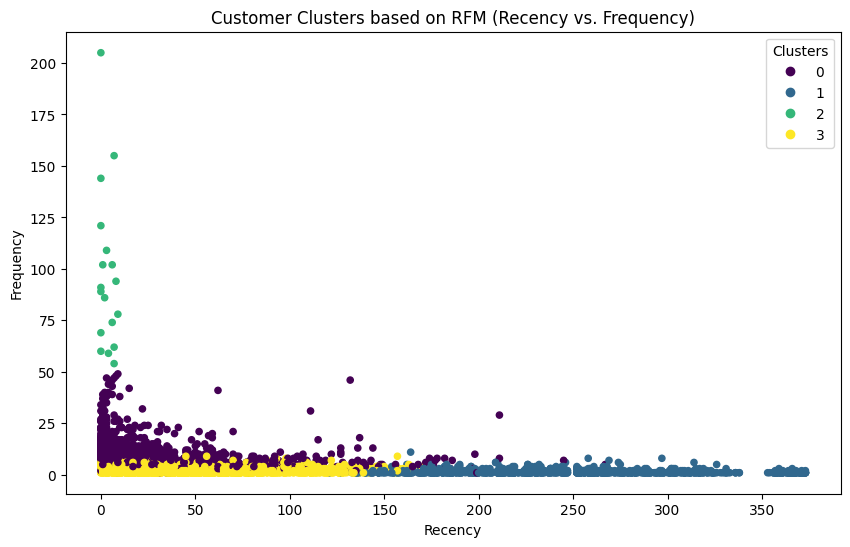

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'], c=rfm_df['Cluster_Label'], cmap='viridis', s=20)

# Add labels and title for the 3D plot
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Clusters based on RFM (3D)')

# Add a legend for the 3D plot
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# Create a 2D scatter plot of Recency vs. Frequency
plt.figure(figsize=(10, 6))
scatter_2d = plt.scatter(rfm_df['Recency'], rfm_df['Frequency'], c=rfm_df['Cluster_Label'], cmap='viridis', s=20)

# Add labels and title for the 2D plot
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Customer Clusters based on RFM (Recency vs. Frequency)')

# Add a legend for the 2D plot
legend_2d = plt.legend(*scatter_2d.legend_elements(), title="Clusters")

# Display the 2D plot
plt.show()

### Customer Clustering using RFM and KMeans

This section performs customer segmentation using the RFM (Recency, Frequency, Monetary) framework and the KMeans clustering algorithm. RFM is a marketing technique used to quantitatively rank and group customers based on their transaction history.

**Steps Involved:**

1.  **Calculate RFM Metrics:** Recency (days since last purchase), Frequency (number of purchases), and Monetary (total amount spent) are calculated for each customer.
2.  **Transform and Scale RFM Data:** To prepare the data for KMeans, the Monetary value is often logarithmically transformed to handle skewed distributions, and then all RFM metrics are scaled using StandardScaler to have a mean of 0 and a standard deviation of 1. This ensures that each feature contributes equally to the clustering process.
3.  **Apply KMeans Clustering:** The KMeans algorithm is applied to the scaled RFM data to group customers into a predefined number of clusters. The number of clusters can be chosen based on business requirements or methods like the elbow method or silhouette score.
4.  **Analyze Clusters:** The mean RFM values for each cluster are calculated and analyzed to understand the characteristics of each segment. This helps in identifying different customer groups, such as high-value customers, recent customers, or inactive customers (decayed/at-risk).
5.  **Visualize Clusters:** The clusters are visualized using scatter plots (2D and 3D if applicable) to show the distribution of customers in the RFM space and how the clusters separate them.

The output includes the RFM DataFrame with cluster labels, the cluster analysis showing mean RFM values per cluster, identification of decayed/at-risk clusters based on the analysis, and visualizations of the customer clusters.

#Machine Learning Prediction

In [ ]:
# 1. Create a binary target variable is_inactive in the customer_last_purchase DataFrame.
customer_inactivity_threshold = customer_last_purchase['InactivityDays'].quantile(0.75)
customer_last_purchase['is_inactive'] = (customer_last_purchase['InactivityDays'] > customer_inactivity_threshold).astype(int)

# 2. Select the InactivityDays and DecayScore columns from customer_last_purchase as features
customer_features = customer_last_purchase[['InactivityDays', 'DecayScore']]

# 3. Create a binary target variable is_inactive in the product_last_sale DataFrame.
product_inactivity_threshold = product_last_sale['InactivityDays'].quantile(0.75)
product_last_sale['is_inactive'] = (product_last_sale['InactivityDays'] > product_inactivity_threshold).astype(int)

# 4. Select the InactivityDays and DecayScore columns from product_last_sale as features
product_features = product_last_sale[['InactivityDays', 'DecayScore']]

# 5. Display the head of customer_features and product_features DataFrames.
print("Customer Features:")
display(customer_features.head())

print("\nProduct Features:")
display(product_features.head())

# 6. Display the value counts of the is_inactive target variable for both customer and product dataframes
print("\nCustomer Inactivity Value Counts:")
display(customer_last_purchase['is_inactive'].value_counts())

print("\nProduct Inactivity Value Counts:")
display(product_last_sale['is_inactive'].value_counts())

Customer Features:


,InactivityDays,DecayScore
0,164,0.439678
1,2,0.005362
2,73,0.195710
3,42,0.112601
4,10,0.026810



Product Features:


,InactivityDays,DecayScore
0,0,0.000000
1,18,0.048257
2,371,0.994638
3,1,0.002681
4,1,0.002681



Customer Inactivity Value Counts:


,count
is_inactive,
0,3236
1,1076



Product Inactivity Value Counts:


,count
is_inactive,
0,3013
1,1004


In [ ]:
from sklearn.model_selection import train_test_split

# Split customer data
X_train_customer, X_test_customer, y_train_customer, y_test_customer = train_test_split(
    customer_features, customer_last_purchase['is_inactive'], test_size=0.2, random_state=42
)

# Split product data
X_train_product, X_test_product, y_train_product, y_test_product = train_test_split(
    product_features, product_last_sale['is_inactive'], test_size=0.2, random_state=42
)

# Print the shapes
print("Customer Data Shapes:")
print("X_train_customer:", X_train_customer.shape)
print("X_test_customer:", X_test_customer.shape)
print("y_train_customer:", y_train_customer.shape)
print("y_test_customer:", y_test_customer.shape)

print("\nProduct Data Shapes:")
print("X_train_product:", X_train_product.shape)
print("X_test_product:", X_test_product.shape)
print("y_train_product:", y_train_product.shape)
print("y_test_product:", y_test_product.shape)

Customer Data Shapes:
X_train_customer: (3449, 2)
X_test_customer: (863, 2)
y_train_customer: (3449,)
y_test_customer: (863,)

Product Data Shapes:
X_train_product: (3213, 2)
X_test_product: (804, 2)
y_train_product: (3213,)
y_test_product: (804,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Instantiate and train Logistic Regression model for customer inactivity
lr_customer = LogisticRegression(random_state=42, solver='liblinear')
lr_customer.fit(X_train_customer, y_train_customer)

# Instantiate and train Random Forest model for customer inactivity
rf_customer = RandomForestClassifier(random_state=42, n_estimators=100)
rf_customer.fit(X_train_customer, y_train_customer)

# Instantiate and train XGBoost model for customer inactivity
xgb_customer = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_customer.fit(X_train_customer, y_train_customer)

# Instantiate and train Logistic Regression model for product inactivity
lr_product = LogisticRegression(random_state=42, solver='liblinear')
lr_product.fit(X_train_product, y_train_product)

# Instantiate and train Random Forest model for product inactivity
rf_product = RandomForestClassifier(random_state=42, n_estimators=100)
rf_product.fit(X_train_product, y_train_product)

# Instantiate and train XGBoost model for product inactivity
xgb_product = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_product.fit(X_train_product, y_train_product)

print("Logistic Regression, Random Forest, and XGBoost models trained for both customer and product inactivity.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:41:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logistic Regression, Random Forest, and XGBoost models trained for both customer and product inactivity.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:41:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate Logistic Regression for customer inactivity
y_pred_lr_customer = lr_customer.predict(X_test_customer)
accuracy_lr_customer = accuracy_score(y_test_customer, y_pred_lr_customer)
precision_lr_customer = precision_score(y_test_customer, y_pred_lr_customer)
recall_lr_customer = recall_score(y_test_customer, y_pred_lr_customer)
f1_lr_customer = f1_score(y_test_customer, y_pred_lr_customer)

print("Logistic Regression - Customer Inactivity:")
print(f"  Accuracy: {accuracy_lr_customer:.4f}")
print(f"  Precision: {precision_lr_customer:.4f}")
print(f"  Recall: {recall_lr_customer:.4f}")
print(f"  F1-Score: {f1_lr_customer:.4f}")

# Evaluate Random Forest for customer inactivity
y_pred_rf_customer = rf_customer.predict(X_test_customer)
accuracy_rf_customer = accuracy_score(y_test_customer, y_pred_rf_customer)
precision_rf_customer = precision_score(y_test_customer, y_pred_rf_customer)
recall_rf_customer = recall_score(y_test_customer, y_pred_rf_customer)
f1_rf_customer = f1_score(y_test_customer, y_pred_rf_customer)

print("\nRandom Forest - Customer Inactivity:")
print(f"  Accuracy: {accuracy_rf_customer:.4f}")
print(f"  Precision: {precision_rf_customer:.4f}")
print(f"  Recall: {recall_rf_customer:.4f}")
print(f"  F1-Score: {f1_rf_customer:.4f}")

# Evaluate XGBoost for customer inactivity
y_pred_xgb_customer = xgb_customer.predict(X_test_customer)
accuracy_xgb_customer = accuracy_score(y_test_customer, y_pred_xgb_customer)
precision_xgb_customer = precision_score(y_test_customer, y_pred_xgb_customer)
recall_xgb_customer = recall_score(y_test_customer, y_pred_xgb_customer)
f1_xgb_customer = f1_score(y_test_customer, y_pred_xgb_customer)

print("\nXGBoost - Customer Inactivity:")
print(f"  Accuracy: {accuracy_xgb_customer:.4f}")
print(f"  Precision: {precision_xgb_customer:.4f}")
print(f"  Recall: {recall_xgb_customer:.4f}")
print(f"  F1-Score: {f1_xgb_customer:.4f}")

# Evaluate Logistic Regression for product inactivity
y_pred_lr_product = lr_product.predict(X_test_product)
accuracy_lr_product = accuracy_score(y_test_product, y_pred_lr_product)
precision_lr_product = precision_score(y_test_product, y_pred_lr_product)
recall_lr_product = recall_score(y_test_product, y_pred_lr_product)
f1_lr_product = f1_score(y_test_product, y_pred_lr_product)

print("\nLogistic Regression - Product Inactivity:")
print(f"  Accuracy: {accuracy_lr_product:.4f}")
print(f"  Precision: {precision_lr_product:.4f}")
print(f"  Recall: {recall_lr_product:.4f}")
print(f"  F1-Score: {f1_lr_product:.4f}")

# Evaluate Random Forest for product inactivity
y_pred_rf_product = rf_product.predict(X_test_product)
accuracy_rf_product = accuracy_score(y_test_product, y_pred_rf_product)
precision_rf_product = precision_score(y_test_product, y_pred_rf_product)
recall_rf_product = recall_score(y_test_product, y_pred_rf_product)
f1_rf_product = f1_score(y_test_product, y_pred_rf_product)

print("\nRandom Forest - Product Inactivity:")
print(f"  Accuracy: {accuracy_rf_product:.4f}")
print(f"  Precision: {precision_rf_product:.4f}")
print(f"  Recall: {recall_rf_product:.4f}")
print(f"  F1-Score: {f1_rf_product:.4f}")

# Evaluate XGBoost for product inactivity
y_pred_xgb_product = xgb_product.predict(X_test_product)
accuracy_xgb_product = accuracy_score(y_test_product, y_pred_xgb_product)
precision_xgb_product = precision_score(y_test_product, y_pred_xgb_product)
recall_xgb_product = recall_score(y_test_product, y_pred_xgb_product)
f1_xgb_product = f1_score(y_test_product, y_pred_xgb_product)

print("\nXGBoost - Product Inactivity:")
print(f"  Accuracy: {accuracy_xgb_product:.4f}")
print(f"  Precision: {precision_xgb_product:.4f}")
print(f"  Recall: {recall_xgb_product:.4f}")
print(f"  F1-Score: {f1_xgb_product:.4f}")

Logistic Regression - Customer Inactivity:
  Accuracy: 0.9954
  Precision: 0.9819
  Recall: 1.0000
  F1-Score: 0.9909

Random Forest - Customer Inactivity:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

XGBoost - Customer Inactivity:
  Accuracy: 0.9965
  Precision: 1.0000
  Recall: 0.9862
  F1-Score: 0.9930

Logistic Regression - Product Inactivity:
  Accuracy: 0.9963
  Precision: 1.0000
  Recall: 0.9854
  F1-Score: 0.9927

Random Forest - Product Inactivity:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000

XGBoost - Product Inactivity:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000


### Machine Learning Models for Inactivity Prediction

This section trains and evaluates several classification models to predict customer and product inactivity based on their calculated inactivity metrics (Inactivity Days and Decay Score). Predicting inactivity can help identify customers or products at risk of churn or becoming obsolete, allowing for targeted interventions.

**Steps Involved:**

1.  **Prepare Data and Target Variable:** A binary target variable `is_inactive` is created for both customer and product dataframes. This variable is typically set based on a predefined threshold of `InactivityDays` (e.g., customers/products with inactivity days above the 75th percentile are considered inactive). The `InactivityDays` and `DecayScore` are selected as features for the models.
2.  **Split Data:** The data is split into training and testing sets to train the models on a portion of the data and evaluate their performance on unseen data.
3.  **Train Models:** Several classification models are instantiated and trained on the training data. Common choices for binary classification tasks like this include:
    *   **Logistic Regression:** A linear model that estimates the probability of the target variable belonging to a particular class.
    *   **Random Forest Classifier:** An ensemble learning method that builds multiple decision trees and combines their predictions.
    *   **XGBoost Classifier:** Another powerful gradient boosting algorithm that is known for its performance.
4.  **Evaluate Models:** The trained models are evaluated on the test data using various classification metrics to assess their performance. Key metrics include:
    *   **Accuracy:** The proportion of correctly classified instances.
    *   **Precision:** The proportion of correctly predicted positive instances among all instances predicted as positive. Useful when the cost of false positives is high.
    *   **Recall:** The proportion of correctly predicted positive instances among all actual positive instances. Useful when the cost of false negatives is high (e.g., failing to identify an inactive customer).
    *   **F1-Score:** The harmonic mean of precision and recall, providing a balanced measure of the model's performance.

The output includes the prepared features and target variables, the shapes of the training and testing sets, confirmation of model training, and the evaluation metrics (Accuracy, Precision, Recall, and F1-Score) for each model on both customer and product inactivity prediction tasks.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# --- Fix for Customer Inactivity Prediction ---
print("--- Updating Customer Features for ML ---")

# Merge rfm_df (containing Recency, Frequency, Monetary) with customer_last_purchase (containing 'is_inactive')
# Ensure 'rfm_df' and 'customer_last_purchase' are available from previous executed cells.
customer_ml_df = rfm_df.merge(customer_last_purchase[['Customer ID', 'is_inactive']], on='Customer ID', how='inner')

# Define new customer features: Recency, Frequency, Monetary
customer_features_new = customer_ml_df[['Recency', 'Frequency', 'Monetary']]
customer_target_new = customer_ml_df['is_inactive']

# Scale the new customer features
scaler_customer_ml = StandardScaler()
customer_features_scaled = scaler_customer_ml.fit_transform(customer_features_new)
customer_features_scaled = pd.DataFrame(customer_features_scaled,
                                        columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
                                        index=customer_features_new.index)

# Re-split customer data with the new features
X_train_customer, X_test_customer, y_train_customer, y_test_customer = train_test_split(
    customer_features_scaled, customer_target_new, test_size=0.2, random_state=42
)

print("Customer Data Shapes (Updated):")
print("X_train_customer:", X_train_customer.shape)
print("X_test_customer:", X_test_customer.shape)
print("y_train_customer:", y_train_customer.shape)
print("y_test_customer:", y_test_customer.shape)


# --- Fix for Product Inactivity Prediction ---
print("\n--- Updating Product Features for ML ---")

# Calculate new product-level features from the main dataframe 'df'
# Ensure 'df' and 'product_last_sale' are available from previously executed cells.
product_stats = df.groupby('StockCode').agg(
    TotalQuantitySold=('Quantity', 'sum'),
    NumCustomers=('Customer ID', 'nunique'), # Number of unique customers who bought this product
    AveragePrice=('Price', 'mean')
).reset_index()

# Merge product_stats with product_last_sale to get the 'is_inactive' target
product_ml_df = product_last_sale.merge(product_stats, on='StockCode', how='inner')

# Define new product features: TotalQuantitySold, NumCustomers, AveragePrice
product_features_new = product_ml_df[['TotalQuantitySold', 'NumCustomers', 'AveragePrice']]
product_target_new = product_ml_df['is_inactive']

# Scale the new product features
scaler_product_ml = StandardScaler()
product_features_scaled = scaler_product_ml.fit_transform(product_features_new)
product_features_scaled = pd.DataFrame(product_features_scaled,
                                        columns=['TotalQuantitySold_scaled', 'NumCustomers_scaled', 'AveragePrice_scaled'],
                                        index=product_features_new.index)

# Re-split product data with the new features
X_train_product, X_test_product, y_train_product, y_test_product = train_test_split(
    product_features_scaled, product_target_new, test_size=0.2, random_state=42
)

print("Product Data Shapes (Updated):")
print("X_train_product:", X_train_product.shape)
print("X_test_product:", X_test_product.shape)
print("y_train_product:", y_train_product.shape)
print("y_test_product:", y_test_product.shape)

print("\nFeature sets for Machine Learning models have been updated to address data leakage.")
print("Please run the subsequent cells for model training and evaluation again to see the updated metrics.")

--- Updating Customer Features for ML ---


NameError: name 'rfm_df' is not defined